# ASD FieldSpec 4 and SVC HR-1024i: uncertainty propagation from raw signal (DN) to reflectance and vegetation indices

**Reference:** Werfeli, M., Antala, M., Abdelmajeed, A.Y.A., Sánchez-Virosta, Á., Halem, Z., Merrington, A., El-Mejjaouy, Y., Petrovic, B., Hueni, A., Bouras, E.H., Kefauver, S.C., Shafiee, S., Rastogi, A., Mihai, L. (2026). *Uncertainty propagation and intercomparison of multi-sensor measurements of vegetation stress in sub-optimal conditions.* Precision Agric 27, 153. https://doi.org/10.1007/s11119-026-10455-1

In [1]:
# =====================================================================================
# OVERVIEW
# INPUT DATA        : raw field-day exports of the ASD FieldSpec 4 and the SVC HR-1024i (Plot 103 and the
#                     following Plot 105, Norway 2025): one row per scan, instrument metadata plus one column
#                     per wavelength (raw digital numbers, DN). A row is a target scan (ASD: 5 positions x 5 scans,
#                     SVC: 4 positions x 5 scans) or a white-panel scan; the 'File Name' column tells which
#                     (fsfwr = panel WP1/AM, laurawr = panel WP2/LM).
#                     Calibration certificates and uncertainties of the two white reference panels
#                     (WP2 has a NIST-traceable certificate, WP1 has none).
# ASSUMPTIONS       : the instruments' own radiometric calibration is not part of this code (start from raw DN);
#                     target and panel are not measured at the same instant, so the panel signal is interpolated
#                     in time to the acquisition time of each target scan; the effect of changing clouds is
#                     estimated from sequential panel measurements; the panel certificate uncertainty and the
#                     plot inhomogeneity are systematic (fully correlated over wavelength).
# UNCERTAINTY MODEL : R = DN_T / DN_R * rho_R * c_clouds
#                       random      : repeat-scan standard error of the panel signal, propagated through the time
#                                     interpolation and the reflectance formula (punpy, Monte Carlo, 10^4 samples)
#                       systematic  : panel certificate (k=2 converted to k=1), clouds, plot inhomogeneity
#                       combination : random and systematic parts are added as covariance matrices, which keeps
#                                     the correlation between wavelengths.
#                     Vegetation indices: propagated with punpy using the correlation of the reflectance errors
#                     at the bands each index needs.
# STEPS (for each instrument) : 1 read raw data    2 panel certificates    3 reflectance formula and time interpolation
#                     4 reflectance of every target scan    5 random uncertainty    6 systematic uncertainty
#                     7 combination with punpy    8 comparison of u_total with the campaign result
#                     9 vegetation indices    10 comparison with the campaign indices
# OUTPUT            : reflectance spectrum of Plot 103 with random, systematic and combined uncertainty;
#                     NDVI, EVI, OSAVI, MTCI, PRI with random, systematic and combined uncertainty.
# =====================================================================================

import numpy as np
import pandas as pd
from scipy.interpolate import CubicSpline, PchipInterpolator
import punpy
import comet_maths as ctm
import matplotlib.pyplot as plt

# Folder with the Plot 103 data, and the files of the instrument and of the two white reference panels
DATA_DIR = "../data/case-asd-svc-plot103"
RAW_PATH = f"{DATA_DIR}/raw_ASD_plot103_105.csv"
# panel certificates (reflectance factor) and their uncertainties; WP1 = 'AM' panel, WP2 = 'LM' panel
PANEL_AM_PATH = f"{DATA_DIR}/panel_certificate_WP1_AM.csv"      # WP1 / "AM" / Alex's panel
PANEL_LM_PATH = f"{DATA_DIR}/panel_certificate_WP2_LM.csv"      # WP2 / "LM" / Laura's panel
U_PANEL_AM_PATH = f"{DATA_DIR}/panel_uncertainty_WP1_AM.csv"
U_PANEL_LM_PATH = f"{DATA_DIR}/panel_uncertainty_WP2_LM.csv"

# Number of Monte Carlo realisations used by punpy in every propagation step
realisations_n = int(1e4)

# ASD FieldSpec 4

## ASD - Step 1: read the raw data

In [2]:
# Step 1a: helper to convert an acquisition time to seconds since midnight
# Convert a datetime.time (or array of them) to seconds since midnight.
def time_to_seconds(t):
    if type(t) == np.ndarray:
        return [i.hour * 3600 + i.minute * 60 + i.second for i in t]
    elif type(t) != list:
        return t.hour * 3600 + t.minute * 60 + t.second


# Step 1b: split the raw export into target scans, WP1/AM panel scans and WP2/LM panel scans for each plot
# (the 'File Name' column identifies the type of each row); returns the spectra, the acquisition times and the wavelengths
def read_Field_day_csv(path, plot_no):
    df = pd.read_csv(path, low_memory=False)
    wvl_idx, plot_idx = 22, 10  # fixed column layout of the ASD field-day export

    L_data = df.iloc[:, wvl_idx:]
    wvls = L_data.columns.astype(float).tolist()

    plot_data_dict, WR_LM_dict, WR_AM_dict = {}, {}, {}
    plot_names = np.asarray(df.iloc[:, plot_idx].tolist())
    t_stamps = pd.to_datetime(df['Acquisition Time']).dt.time.to_numpy()

    for pid in plot_no:
        positions_fsf = np.asarray([i for i, s in enumerate(plot_names) if "fsfwr" in s and pid in s])
        positions_laura = np.asarray([i for i, s in enumerate(plot_names) if "laurawr" in s and pid in s])

        WR_AM_dict[pid] = (np.asarray(L_data.iloc[positions_fsf, :]), np.asarray(t_stamps[positions_fsf]))
        WR_LM_dict[pid] = (np.asarray(L_data.iloc[positions_laura, :]), np.asarray(t_stamps[positions_laura]))

        position_plot = np.asarray([i for i, s in enumerate(plot_names) if pid in s])
        mask = ~np.isin(position_plot, np.concatenate([positions_fsf, positions_laura]))
        position_plot = position_plot[mask]
        plot_data_dict[pid] = (np.asarray(L_data.iloc[position_plot, :]), np.asarray(t_stamps[position_plot]))

    return plot_data_dict, WR_LM_dict, WR_AM_dict, wvls


# Step 1c: read Plot 103 and the next plot (105): the panel measured at Plot 105 is needed to interpolate the panel signal in time
plot_no = ['103', '105']
L, WR_LM, WR_AM, wvls = read_Field_day_csv(RAW_PATH, plot_no)

print(f"{len(L['103'][0])} target scans for plot 103")
print(f"{len(WR_AM['103'][0])} WP1/AM panel scans, {len(WR_LM['103'][0])} WP2/LM panel scans for plot 103")

25 target scans for plot 103
5 WP1/AM panel scans, 5 WP2/LM panel scans for plot 103


## ASD - Step 2: panel calibration certificates

In [3]:
# Step 2a: read the certificate of a white reference panel (reflectance factor rho, or its uncertainty) and interpolate it
# onto the 1 nm wavelength grid of the instrument (cubic spline; PCHIP for the uncertainty). The two panels have different certificate formats.
def rho_panel_interp(file_path, wvls, wvls_range=(350, 2500)):
    wvls = np.asarray(wvls)
    if 'WP1_AM' in file_path:
        df = pd.read_csv(file_path)
        wvls_rho = np.asanyarray(df['lambda'])
        idx = np.where((wvls_rho >= wvls_range[0]) & (wvls_rho <= wvls_range[1]))[0]
        col = 'sigma (k=2)' if 'uncertainty' in file_path else 'rho'
        rho_interp = np.asarray(df[col][idx])
        wvls_rho = wvls_rho[idx]
        cs = PchipInterpolator(wvls_rho, rho_interp) if 'uncertainty' in file_path else CubicSpline(wvls_rho, rho_interp)
        wvls_new = np.arange(wvls_range[0], wvls_range[1] + 1)
        return cs(wvls_new)
    elif 'WP2_LM' in file_path:
        df = pd.read_csv(file_path)
        if 'uncertainty' in file_path:
            wvls_rho = np.asarray(df.iloc[:, 0])
            idx = np.where((wvls_rho >= wvls_range[0]) & (wvls_rho <= wvls_range[1]))[0]
            u_raw = np.asarray(df.iloc[idx, 1])
            cs = PchipInterpolator(wvls_rho[idx], u_raw)
            return cs(np.arange(wvls_range[0], wvls_range[1] + 1))
        wvls_rho = np.asarray(df.iloc[:, 0])
        idx = np.where((wvls_rho >= wvls_range[0]) & (wvls_rho <= wvls_range[1]))[0]
        rho_raw = np.asarray(df.iloc[idx, 1])
        rho_raw_dec = np.asarray(df.iloc[idx, 2])
        # the certificate stores reflectance as separate integer/decimal columns; recombine into one float
        num_digits = np.floor(np.log10(rho_raw_dec) + 1).astype(int)
        rho_raw = (rho_raw + rho_raw_dec / (10 ** num_digits)) / 100
        rho = np.ones(len(wvls))
        wvls_rho2 = wvls_rho[idx]
        cs = CubicSpline(wvls_rho2, rho_raw)
        wvls_ip = np.arange(wvls_range[0], wvls_rho[max(idx)])
        rho_interp = cs(wvls_ip)
        rho[:len(rho_raw) - 1] *= rho_interp
        ones_idx = np.where(rho == 1)
        if len(ones_idx[0]) > 0:
            rho[ones_idx] *= rho_interp[ones_idx[0][0] - 1]
        return rho


# Step 2b: reflectance factor of each panel and its absolute uncertainty (certificate uncertainty at k=2, divided by 2 to get k=1)
rho_interp_AM = rho_panel_interp(PANEL_AM_PATH, wvls)
rho_interp_LM = rho_panel_interp(PANEL_LM_PATH, wvls)
u_rho_am_abs = rho_interp_AM * (rho_panel_interp(U_PANEL_AM_PATH, wvls) / 2)
u_rho_lm_abs = rho_interp_LM * (rho_panel_interp(U_PANEL_LM_PATH, wvls) / 2)

print(f"WP1/AM panel reflectance factor at 550nm: {rho_interp_AM[list(np.arange(350,2501)).index(550)]:.4f}")

WP1/AM panel reflectance factor at 550nm: 0.9922


## ASD - Step 3: reflectance formula and time interpolation

In [4]:
# Step 3a: linear interpolation in time of the panel signal to the acquisition time of the target scan.
# The function accepts punpy's Monte Carlo sample arrays (extra dimension n_MC) as well as single spectra.
# Interpolate the white-reference-panel signal to the target's acquisition
# time. Built to accept punpy's Monte Carlo sample arrays (extra dimension
# n_MC), not just single spectra.
def irradiance_interpol(E_start, E_end, E_start_t, E_end_t, L_t):
    if E_start.ndim == 1:
        E_start, E_end = E_start[:, None], E_end[:, None]
        E_start_t, E_end_t, L_t = np.atleast_1d(E_start_t), np.atleast_1d(E_end_t), np.atleast_1d(L_t)
    n_bands, n_MC = E_start.shape
    E_interp = np.empty((n_bands, n_MC))
    for k in range(n_MC):
        t = np.array([E_start_t[k], E_end_t[k]])
        for i in range(n_bands):
            E_interp[i, k] = np.interp(L_t[k], t, np.array([E_start[i, k], E_end[i, k]]))
    return E_interp


# Step 3b: reflectance R = DN_target / DN_panel * rho_panel * c_cloud
def refl_calculator(DN_target, DN_panel_interp, rho_panel, c_cloud):
    return DN_target / DN_panel_interp * rho_panel * c_cloud


# Step 3c: mean panel signal and mean acquisition time at Plot 103 (start) and at the following Plot 105 (end), for each panel
# White-reference panel readings for plot 103, and the next plot (105) they
# are interpolated towards.
E_start_AM = np.mean(WR_AM['103'][0], axis=0)
E_end_AM = np.mean(WR_AM['105'][0], axis=0)
E_start_t_AM = np.mean(time_to_seconds(WR_AM['103'][1]))
E_end_t_AM = np.mean(time_to_seconds(WR_AM['105'][1]))

E_start_LM = np.mean(WR_LM['103'][0], axis=0)
E_end_LM = np.mean(WR_LM['105'][0], axis=0)
E_start_t_LM = np.mean(time_to_seconds(WR_LM['103'][1]))
E_end_t_LM = np.mean(time_to_seconds(WR_LM['105'][1]))

## ASD - Step 4: reflectance of every target scan

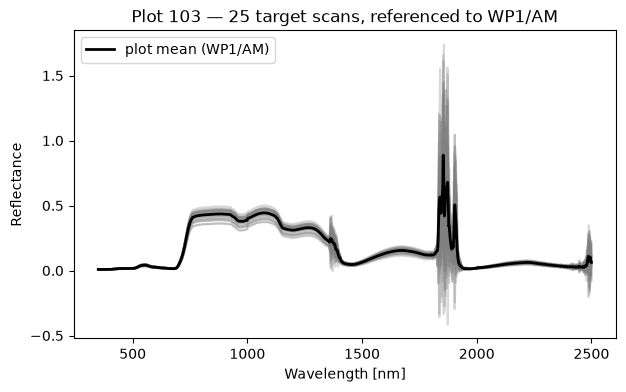

In [5]:
# Step 4a: reflectance of every target scan of Plot 103, for both panels (the same targets referenced two ways):
# the panel signal is interpolated to the scan time and the reflectance formula is applied (c_cloud = 1 here; its
# uncertainty is added in the systematic propagation, Step 7)
R_dict, E_interp_dict = {}, {}

for panel_name, (E_start, E_end, E_start_t, E_end_t, rho) in {
    'AM': (E_start_AM, E_end_AM, E_start_t_AM, E_end_t_AM, rho_interp_AM),
    'LM': (E_start_LM, E_end_LM, E_start_t_LM, E_end_t_LM, rho_interp_LM),
}.items():
    R_list, E_interp_list = [], []
    for i in range(len(L['103'][0])):
        DN = L['103'][0][i]
        DN_t = time_to_seconds(L['103'][1][i])
        c_cloud = np.ones(len(DN))
        E_interp = np.squeeze(irradiance_interpol(E_start, E_end, E_start_t, E_end_t, DN_t))
        R = refl_calculator(DN, E_interp, rho, c_cloud)
        R_list.append(R)
        E_interp_list.append(E_interp)
    R_dict['103_' + panel_name] = R_list
    E_interp_dict['103_' + panel_name] = E_interp_list[-1]  # last E_interp reused below for the uncertainty budget

# Step 4b: plot all scans (grey) and the plot mean
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))
for r in R_dict['103_AM']:
    plt.plot(wvls, r, color='grey', alpha=0.3)
plt.plot(wvls, np.mean(R_dict['103_AM'], axis=0), color='k', linewidth=2, label='plot mean (WP1/AM)')
plt.xlabel('Wavelength [nm]'); plt.ylabel('Reflectance'); plt.legend(); plt.title('Plot 103 — 25 target scans, referenced to WP1/AM')
plt.show()

## ASD - Step 5: random uncertainty (sensor noise)

In [6]:
# Step 5a: every panel scan expressed as a ratio to the mean panel signal (a number close to 1)
R_WR_dict = {}
for panel_name, (WR_readings, E_ref) in {
    'AM': (WR_AM['103'][0], E_start_AM),
    'LM': (WR_LM['103'][0], E_start_LM),
}.items():
    R_WR_dict['103_' + panel_name] = [scan / E_ref for scan in WR_readings]

# Step 5b: the standard error of that ratio over the repeated panel scans is the fractional random uncertainty
# (also used for the target signal); a small positive floor avoids zero uncertainty
WR_sd = {}
for key in R_WR_dict.keys():
    N = len(R_WR_dict[key])
    sd = np.std(R_WR_dict[key], axis=0, ddof=1) / np.sqrt(N)  # fractional standard error of the panel ratio
    eps = 1e-6 * np.nanmax(sd)  # strictly-positive floor, avoids zero-uncertainty edge cases
    WR_sd[key] = np.maximum(sd, eps)

print("Random (fractional) sensor-noise uncertainty at 550nm, WP1/AM:", WR_sd['103_AM'][list(np.arange(350,2501)).index(550)])

Random (fractional) sensor-noise uncertainty at 550nm, WP1/AM: 0.009108843158916633


## ASD - Step 6: systematic uncertainty (clouds and plot inhomogeneity)

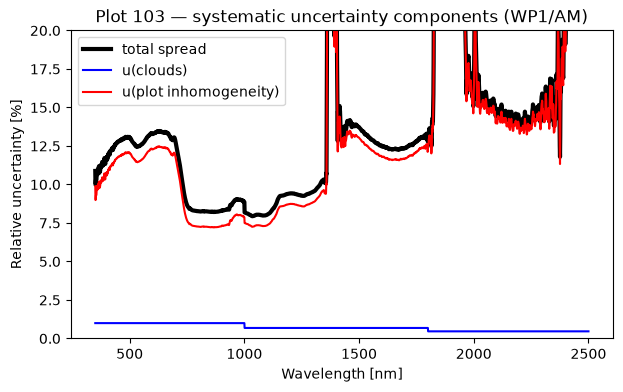

In [7]:
# Step 6a: cloud-driven uncertainty. Panel signals of consecutive plots are regressed against each other for three
# wavelength pairs (400-900 nm, 400-1600 nm, 400-2200 nm, for VNIR, SWIR1 and SWIR2); the mean relative residual of the
# regression is u(clouds)
def u_cloud_estimation(WR_DN_dict, wvls):
    results = {}
    wvls = np.asarray(wvls)
    pairs = [(np.argmin(np.abs(wvls - 400)), np.argmin(np.abs(wvls - 900))),
             (np.argmin(np.abs(wvls - 400)), np.argmin(np.abs(wvls - 1600))),
             (np.argmin(np.abs(wvls - 400)), np.argmin(np.abs(wvls - 2200)))]
    keys = list(WR_DN_dict.keys())
    for i, key in enumerate(keys):
        if i + 1 >= len(keys):
            continue
        WR_DN = np.vstack([np.asarray(WR_DN_dict[key]), np.asarray(WR_DN_dict[keys[i + 1]])])
        key_results = {}
        for i_pair, (w1, w2) in enumerate(pairs):
            x, y = WR_DN[:, w1], WR_DN[:, w2]
            slope, intercept = np.polyfit(x, y, deg=1)
            residuals_rel = np.abs((slope * x + intercept) - y) / y * 100
            key_results[f"pair{i_pair+1}"] = {"residuals_rel_mean": np.mean(residuals_rel)}
        results[key] = key_results
    return results


# Step 6b: pair each plot with the following plot (103 with 105)
# WR_DN_dict pairs plot 103 with the next plot (105) exactly as the
# original 8-plot campaign loop pairs every plot with the one after it.
WR_DN_dict = {
    '103_AM': WR_AM['103'][0], '105_AM': WR_AM['105'][0],
    '103_LM': WR_LM['103'][0], '105_LM': WR_LM['105'][0],
}
u_cloud_rel = u_cloud_estimation(WR_DN_dict, wvls)

# Step 6c: build u(clouds) as a function of wavelength (constant in each of the three ranges) and average the two panels
vnir = np.ones(len(np.arange(350, 1001)))
swir1 = np.ones(len(np.arange(1001, 1801)))
swir2 = np.ones(len(np.arange(1801, 2501)))

def cloud_curve(key):
    return np.concatenate([u_cloud_rel[key]['pair1']['residuals_rel_mean'] * vnir,
                            u_cloud_rel[key]['pair2']['residuals_rel_mean'] * swir1,
                            u_cloud_rel[key]['pair3']['residuals_rel_mean'] * swir2])

plot_u_clouds = np.mean(np.stack([cloud_curve('103_LM'), cloud_curve('103_AM')], axis=0), axis=0)

# Step 6d: plot inhomogeneity = spread of the target scans minus the cloud contribution (so that the two components
# are not counted twice); also the correlation matrix between wavelengths of the scans of each plot
plot_sd, plot_mean_refl, plot_inhomogeneity, plot_err_corr = {}, {}, {}, {}
for key in R_dict.keys():
    plot_mean_refl[key] = np.maximum(np.mean(R_dict[key], axis=0), 1e-9)
    plot_sd[key] = np.std(R_dict[key], axis=0) / plot_mean_refl[key] * 100
    plot_inhomogeneity[key] = (plot_sd[key] / 100 * plot_mean_refl[key] - plot_u_clouds / 100 * plot_mean_refl[key]) / plot_mean_refl[key] * 100
    plot_err_corr[key] = np.corrcoef(np.stack(R_dict[key], axis=0), rowvar=False)

# Step 6e: plot the components
plt.figure(figsize=(7, 4))
plt.plot(wvls, plot_sd['103_AM'], 'k', linewidth=3, label='total spread')
plt.plot(wvls, plot_u_clouds, 'b', label='u(clouds)')
plt.plot(wvls, plot_inhomogeneity['103_AM'], 'r', label='u(plot inhomogeneity)')
plt.ylim(0, 20); plt.xlabel('Wavelength [nm]'); plt.ylabel('Relative uncertainty [%]'); plt.legend()
plt.title('Plot 103 — systematic uncertainty components (WP1/AM)')
plt.show()

## ASD - Step 7: combination with punpy

In [8]:
# Step 7a: correlation matrices must be positive definite. regularize_corr projects a matrix onto the nearest valid
# correlation matrix (eigenvalues below a small threshold are raised) before it is given to punpy
def regularize_corr(C, eps=1e-6):
    C = (C + C.T) / 2
    eigval, eigvec = np.linalg.eigh(C)
    C_pd = eigvec @ np.diag(np.clip(eigval, eps, None)) @ eigvec.T
    d = np.sqrt(np.diag(C_pd))
    C_pd = C_pd / np.outer(d, d)
    np.fill_diagonal(C_pd, 1.0)
    return C_pd


# Step 7b: error correlation between wavelengths: plot inhomogeneity and panel calibration are systematic, so fully correlated;
# the cloud term uses the empirical correlation of the scans
err_corr_plot = regularize_corr(np.full((len(wvls), len(wvls)), 1.0))   # plot inhomogeneity: treated as fully correlated across wavelength
rho_err_corr = regularize_corr(np.full((len(wvls), len(wvls)), 1.0))    # panel calibration: fully correlated (systematic by nature)

# Step 7c: propagation for every panel and plot (key = plot_panel); results are collected in dictionaries
prop = punpy.MCPropagation(realisations_n)
u_rand_dict, u_syst_dict, u_combined_dict = {}, {}, {}
err_corr_rand, err_corr_syst, err_corr_combined = {}, {}, {}

for key in R_dict.keys():
    panel = key.split('_')[1]
    E_start, E_end, E_start_t, E_end_t = (E_start_AM, E_end_AM, E_start_t_AM, E_end_t_AM) if panel == 'AM' \
        else (E_start_LM, E_end_LM, E_start_t_LM, E_end_t_LM)
    rho = rho_interp_AM if panel == 'AM' else rho_interp_LM
    u_rho_abs = u_rho_am_abs if panel == 'AM' else u_rho_lm_abs
    # Scale the fractional panel-repeatability uncertainty back up to an
    # absolute uncertainty (in DN) using the panel's own mean signal level.
    # random uncertainty of the panel signal in DN (fractional uncertainty x mean panel signal)
    u_rand_panel = WR_sd[key] / 100 * E_start

    DN = np.mean(L['103'][0], axis=0)
    DN_t = time_to_seconds(L['103'][1][-1])
    E_interp = E_interp_dict[key]
    c_cloud = np.ones(len(DN))
    # systematic uncertainty of the target signal from the plot inhomogeneity
    u_syst_plot = np.maximum(plot_inhomogeneity[key] / 100 * DN, 1e-9)
    err_corr_clouds = regularize_corr(plot_err_corr[key])

    # (the numbered steps below are the steps of the propagation loop)
    # Step 1: propagate the panel's random uncertainty through the time interpolation
    u_E_interp_rand, _ = prop.propagate_random(
        irradiance_interpol,
        [E_start, E_end, np.asarray(E_start_t), np.asarray(E_end_t), np.asarray(DN_t)],
        [u_rand_panel, u_rand_panel, np.asarray(0.1), np.asarray(0.1), np.asarray(0.1)],
        ['rand'] * 5, return_corr=True)
    u_E_interp_rand = np.squeeze(u_E_interp_rand)

    # Step 2: propagate the RANDOM components through the reflectance formula
    u_R_rand, corr_R_rand = prop.propagate_random(
        refl_calculator, [DN, E_interp, rho, c_cloud],
        [u_rand_panel, u_E_interp_rand, np.zeros(len(rho)), np.zeros(len(c_cloud))],
        ['rand'] * 4, return_corr=True)

    # Step 3: propagate the SYSTEMATIC components through the reflectance formula
    u_R_syst, corr_R_syst = prop.propagate_systematic(
        refl_calculator, [DN, E_interp, rho, c_cloud],
        [u_syst_plot, np.zeros(len(E_interp)), u_rho_abs, plot_u_clouds / 100],
        [err_corr_plot, 'syst', rho_err_corr, err_corr_clouds], return_corr=True)

    # Step 4: combine as covariance matrices (keeps the correlation structure), not scalar quadrature
    cov_total = ctm.convert_corr_to_cov(corr_R_rand, u_R_rand) + ctm.convert_corr_to_cov(corr_R_syst, u_R_syst)
    u_total = ctm.uncertainty_from_covariance(cov_total)
    err_corr_rand[key] = corr_R_rand
    err_corr_syst[key] = corr_R_syst
    err_corr_combined[key] = ctm.correlation_from_covariance(cov_total)

    u_rand_dict[key] = u_R_rand
    u_syst_dict[key] = u_R_syst
    u_combined_dict[key] = u_total
    print(f"{key}: done")

/opt/miniconda3/lib/python3.12/site-packages/comet_maths/linear_algebra/matrix_conversion.py:32: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  correlation = np.divide(covariance, outer_v, where=outer_v != 0)


103_AM: done


103_LM: done


## ASD - Step 8: comparison of the combined uncertainty with the campaign result

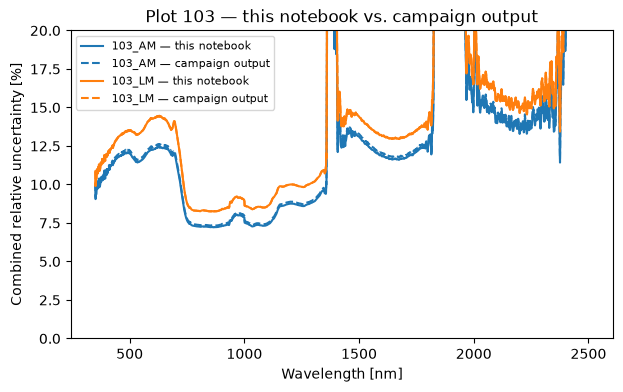

103_AM: median relative difference in u_total vs. campaign = 1.40% (max 1.76%)
103_LM: median relative difference in u_total vs. campaign = 0.04% (max 0.16%)


In [9]:
# Step 8: combined relative uncertainty of this notebook (solid) and of the campaign result (dashed), and their difference
campaign_total = pd.read_csv(f"{DATA_DIR}/../case-intercomparison-plot103/asd_u_total_all_plots.csv", index_col=0)

plt.figure(figsize=(7, 4))
for key, color in [('103_AM', 'tab:blue'), ('103_LM', 'tab:orange')]:
    rel_total = u_combined_dict[key] / plot_mean_refl[key] * 100
    plt.plot(wvls, rel_total, color=color, label=f'{key} — this notebook')
    off = campaign_total[key].values / plot_mean_refl[key] * 100
    plt.plot(wvls, off, color=color, linestyle='--', label=f'{key} — campaign output')
plt.ylim(0, 20); plt.xlabel('Wavelength [nm]'); plt.ylabel('Combined relative uncertainty [%]')
plt.legend(fontsize=8); plt.title('Plot 103 — this notebook vs. campaign output')
plt.show()

for key in ['103_AM', '103_LM']:
    diff = np.abs(u_combined_dict[key] - campaign_total[key].values) / (campaign_total[key].values + 1e-12) * 100
    print(f"{key}: median relative difference in u_total vs. campaign = {np.nanmedian(diff):.2f}% (max {np.nanmax(diff):.2f}%)")

## ASD - Step 9: vegetation indices

In [10]:
# Step 9a: vegetation index functions, correlation helpers and plot functions (the same for ASD and SVC)

WVLS_FULL = np.arange(350, 2501)  # full 1 nm wavelength grid of the instruments

# Vegetation indices (formulas as in the paper, Table 3)
def calc_NDVI(R780, R670): return (R780 - R670) / (R780 + R670)
def calc_EVI(R780, R670, R480): return 2.5 * ((R780 - R670) / (R780 + 6*R670 - 7.5*R480 + 1))
def calc_OSAVI(R780, R670): return 1.16 * ((R780 - R670) / (R780 + R670 + 0.16))
def calc_MTCI(R754, R709, R681): return (R754 - R709) / (R709 - R681)
def calc_PRI(R570, R531): return (R570 - R531) / (R570 + R531)

def idx_of(wvls, target):
    # position of a wavelength in the 1 nm grid
    return np.where(wvls == target)[0][0]

# Correlation of the reflectance errors between the 2 (or 3) bands an index needs,
# taken from the full wavelength-by-wavelength correlation matrix of the reflectance
def corr2(corr_mat, a_idx, b_idx):
    return np.array([[1.0, corr_mat[a_idx, b_idx]],
                     [corr_mat[b_idx, a_idx], 1.0]])

def corr3(corr_mat, i, j, k):
    return np.array([[1.0,            corr_mat[i, j], corr_mat[i, k]],
                     [corr_mat[j, i], 1.0,            corr_mat[j, k]],
                     [corr_mat[k, i], corr_mat[k, j], 1.0]])

def plot_spectrum_with_unc(x, y, u, title):
    # plot-mean reflectance with its combined uncertainty as a band
    plt.figure()
    plt.plot(x, y, label='Reflectance')
    plt.fill_between(x, y-u, y+u, alpha=0.3, label='Uncertainty')
    plt.ylim((0, 1))
    plt.grid()
    plt.legend()
    plt.xlabel('Wavelength [nm]')
    plt.ylabel('Reflectance []')
    plt.title(title)
    plt.show()

def plot_indices_with_unc(NDVI, EVI, OSAVI, MTCI, PRI,
                          u_NDVI, u_EVI, u_OSAVI, u_MTCI, u_PRI, title):
    # one coloured point with error bar per index
    plt.figure()
    plt.errorbar(1,   NDVI,  u_NDVI,  capsize=15, elinewidth=2, fmt='o', color='g', label='NDVI')
    plt.errorbar(1.1, EVI,   u_EVI,   capsize=15, elinewidth=2, fmt='o', color='b', label='EVI')
    plt.errorbar(1.2, OSAVI, u_OSAVI, capsize=15, elinewidth=2, fmt='o', color='r', label='OSAVI')
    plt.errorbar(1.3, MTCI,  u_MTCI,  capsize=15, elinewidth=2, fmt='o', color='k', label='MTCI')
    plt.errorbar(1.4, PRI,   u_PRI,   capsize=15, elinewidth=2, fmt='o', color='c', label='PRI')
    plt.ylabel('Index value []')
    plt.legend()
    plt.title(title)
    plt.xticks([])
    plt.show()

In [11]:
# Step 9b: indices of the plot-mean reflectance with propagated random, systematic and total uncertainty

def vegetation_indices(R_plot, u_total_df, u_rand_df, u_syst_df,
                       err_corr_R_random, err_corr_R_syst, err_corr_R_total):
    # positions of the bands in the 1 nm grid
    idx480 = idx_of(WVLS_FULL, 480); idx531 = idx_of(WVLS_FULL, 531)
    idx570 = idx_of(WVLS_FULL, 570); idx670 = idx_of(WVLS_FULL, 670)
    idx681 = idx_of(WVLS_FULL, 681); idx709 = idx_of(WVLS_FULL, 709)
    idx754 = idx_of(WVLS_FULL, 754); idx780 = idx_of(WVLS_FULL, 780)

    prop = punpy.MCPropagation(int(1e4))
    rows_val, rows_unc = [], []

    for key in u_total_df.columns:
        # plot-mean reflectance (mean over all target scans) and its uncertainties
        R_mean = np.mean(R_plot[key], axis=0)
        u_total_plot = u_total_df[key].to_numpy()
        u_syst_plot = u_syst_df[key].to_numpy()
        u_rand_plot = u_rand_df[key].to_numpy()

        plot_spectrum_with_unc(WVLS_FULL, R_mean, u_total_plot,
                               f"Mean reflectance with uncertainty plot {key}")

        # reflectance, total, random and systematic uncertainty at the bands used by the indices
        R480 = R_mean[idx480]; R531 = R_mean[idx531]; R570 = R_mean[idx570]
        R670 = R_mean[idx670]; R681 = R_mean[idx681]; R709 = R_mean[idx709]
        R754 = R_mean[idx754]; R780 = R_mean[idx780]

        NDVI = calc_NDVI(R780, R670)
        EVI  = calc_EVI(R780, R670, R480)
        OSAVI = calc_OSAVI(R780, R670)
        MTCI = calc_MTCI(R754, R709, R681)
        PRI  = calc_PRI(R570, R531)

        u480 = u_total_plot[idx480]; u531 = u_total_plot[idx531]; u570 = u_total_plot[idx570]
        u670 = u_total_plot[idx670]; u681 = u_total_plot[idx681]; u709 = u_total_plot[idx709]
        u754 = u_total_plot[idx754]; u780 = u_total_plot[idx780]

        ur480 = u_rand_plot[idx480]; ur531 = u_rand_plot[idx531]; ur570 = u_rand_plot[idx570]
        ur670 = u_rand_plot[idx670]; ur681 = u_rand_plot[idx681]; ur709 = u_rand_plot[idx709]
        ur754 = u_rand_plot[idx754]; ur780 = u_rand_plot[idx780]

        us480 = u_syst_plot[idx480]; us531 = u_syst_plot[idx531]; us570 = u_syst_plot[idx570]
        us670 = u_syst_plot[idx670]; us681 = u_syst_plot[idx681]; us709 = u_syst_plot[idx709]
        us754 = u_syst_plot[idx754]; us780 = u_syst_plot[idx780]

        # error correlation matrices of the reflectance (random, systematic, total) for this plot
        corr_r = err_corr_R_random[key]
        corr_s = err_corr_R_syst[key]
        corr_t = err_corr_R_total[key]

        # random part: propagate_random with the random uncertainties and the random correlation;
        # systematic part: propagate_systematic with the systematic ones; total: propagate_standard
        u_NDVI_rand = prop.propagate_random(calc_NDVI, [R780, R670], [ur780, ur670], corr_x=corr2(corr_r, idx780, idx670))
        u_NDVI_syst = prop.propagate_systematic(calc_NDVI, [R780, R670], [us780, us670], corr_x=corr2(corr_s, idx780, idx670))
        u_NDVI      = prop.propagate_standard(calc_NDVI, [R780, R670], [u780,  u670],  corr_x=corr2(corr_t, idx780, idx670))

        u_OSAVI_rand = prop.propagate_random(calc_OSAVI, [R780, R670], [ur780, ur670], corr_x=corr2(corr_r, idx780, idx670))
        u_OSAVI_syst = prop.propagate_systematic(calc_OSAVI, [R780, R670], [us780, us670], corr_x=corr2(corr_s, idx780, idx670))
        u_OSAVI      = prop.propagate_standard(calc_OSAVI, [R780, R670], [u780,  u670],  corr_x=corr2(corr_t, idx780, idx670))

        u_PRI_rand = prop.propagate_random(calc_PRI, [R570, R531], [ur570, ur531], corr_x=corr2(corr_r, idx570, idx531))
        u_PRI_syst = prop.propagate_systematic(calc_PRI, [R570, R531], [us570, us531], corr_x=corr2(corr_s, idx570, idx531))
        u_PRI      = prop.propagate_standard(calc_PRI, [R570, R531], [u570,  u531],  corr_x=corr2(corr_t, idx570, idx531))

        u_EVI_rand = prop.propagate_random(calc_EVI, [R780, R670, R480], [ur780, ur670, ur480], corr_x=corr3(corr_r, idx780, idx670, idx480))
        u_EVI_syst = prop.propagate_systematic(calc_EVI, [R780, R670, R480], [us780, us670, us480], corr_x=corr3(corr_s, idx780, idx670, idx480))
        u_EVI      = prop.propagate_standard(calc_EVI, [R780, R670, R480], [u780,  u670,  u480], corr_x=corr3(corr_t, idx780, idx670, idx480))

        u_MTCI_rand = prop.propagate_random(calc_MTCI, [R754, R709, R681], [ur754, ur709, ur681], corr_x=corr3(corr_r, idx754, idx709, idx681))
        u_MTCI_syst = prop.propagate_systematic(calc_MTCI, [R754, R709, R681], [us754, us709, us681], corr_x=corr3(corr_s, idx754, idx709, idx681))
        u_MTCI      = prop.propagate_standard(calc_MTCI, [R754, R709, R681], [u754,  u709,  u681], corr_x=corr3(corr_t, idx754, idx709, idx681))

        plot_indices_with_unc(NDVI, EVI, OSAVI, MTCI, PRI,
                              u_NDVI, u_EVI, u_OSAVI, u_MTCI, u_PRI,
                              f"Indices calculated for plot {key}")

        f = lambda x: float(np.asarray(x).ravel()[0])
        rows_val.append({"plot ids": key, "NDVI": NDVI, "EVI": EVI, "OSAVI": OSAVI, "MTCI": MTCI, "PRI": PRI})
        rows_unc.append({"plot ids": key,
            "NDVI": f(u_NDVI), "NDVI rand": f(u_NDVI_rand), "NDVI syst": f(u_NDVI_syst),
            "EVI": f(u_EVI),   "EVI rand": f(u_EVI_rand),   "EVI syst": f(u_EVI_syst),
            "OSAVI": f(u_OSAVI), "OSAVI rand": f(u_OSAVI_rand), "OSAVI syst": f(u_OSAVI_syst),
            "MTCI": f(u_MTCI), "MTCI rand": f(u_MTCI_rand), "MTCI syst": f(u_MTCI_syst),
            "PRI": f(u_PRI),   "PRI rand": f(u_PRI_rand),   "PRI syst": f(u_PRI_syst)})

    return pd.DataFrame(rows_val), pd.DataFrame(rows_unc)

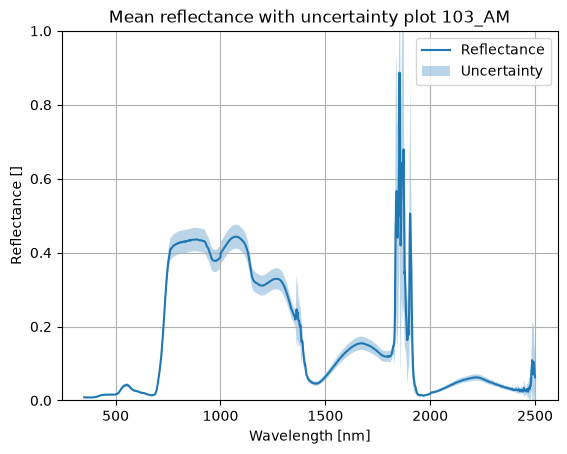

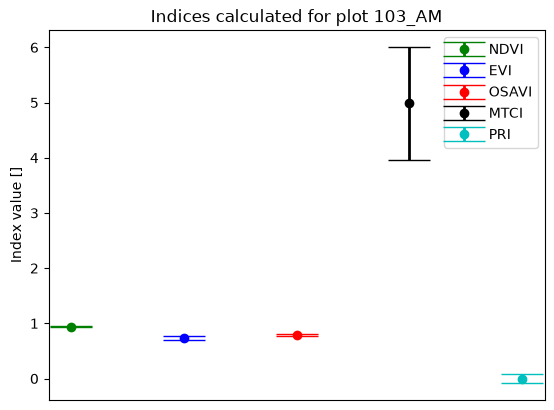

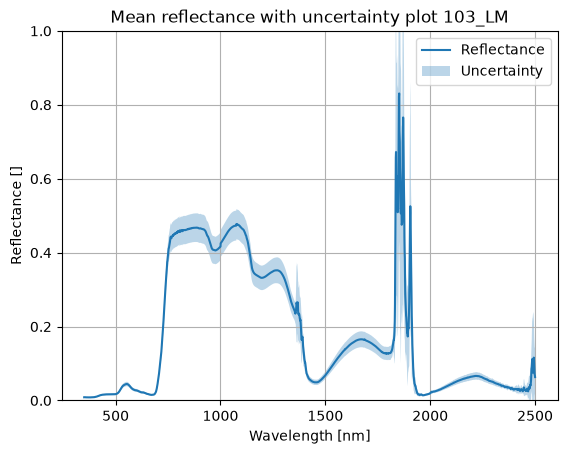

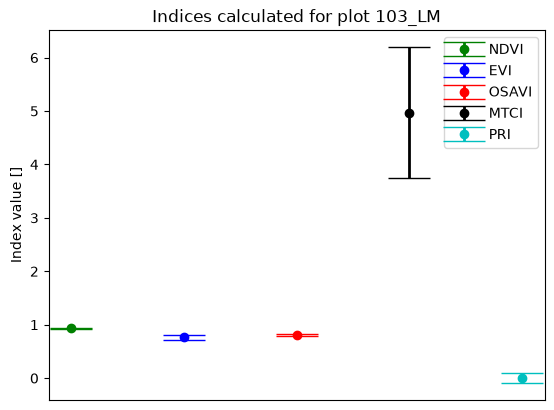

,plot ids,NDVI,EVI,OSAVI,MTCI,PRI
0,103_AM,0.934649,0.731466,0.792357,4.984548,-0.000497
1,103_LM,0.934771,0.766773,0.806732,4.966417,0.000937


,plot ids,NDVI,NDVI rand,NDVI syst,EVI,EVI rand,EVI syst,OSAVI,OSAVI rand,OSAVI syst,MTCI,MTCI rand,MTCI syst,PRI,PRI rand,PRI syst
0,103_AM,0.009155,0.000436,0.008893,0.040671,0.000605,0.041139,0.020345,0.000332,0.019952,1.018473,0.012600,1.048939,0.083474,0.00183,0.082969
1,103_LM,0.010375,0.000387,0.010546,0.048057,0.000575,0.047774,0.022417,0.000300,0.022528,1.228366,0.011313,1.256674,0.095583,0.00159,0.096698


In [12]:
# Step 9c: run for the ASD (both panels): R_dict = reflectance of all scans; the uncertainty dictionaries and
# error-correlation dictionaries come from Step 7
df_indices_ASD, df_unc_ASD = vegetation_indices(
    R_dict, pd.DataFrame(u_combined_dict), pd.DataFrame(u_rand_dict), pd.DataFrame(u_syst_dict),
    err_corr_rand, err_corr_syst, err_corr_combined)
display(df_indices_ASD)
display(df_unc_ASD)

## ASD - Step 10: comparison with the campaign indices

In [13]:
# Campaign indices: workbook Indexes-7_cos_16062026.xlsx, sheet Indexes103 (one row per sensor and panel)
import openpyxl
wb_idx = openpyxl.load_workbook(f"{DATA_DIR}/../case-intercomparison-plot103-full/Indexes-7_cos_16062026.xlsx",
                                data_only=True, read_only=True)
ws_idx = wb_idx["Indexes103"]
# each index occupies 7 columns: point, value, u_r, u_s, u_homogeneity, u_c, U_k2
index_start = {"PRI": 1, "NDVI": 7, "NIRv": 13, "EVI": 19, "MTCI": 25, "OSAVI": 31}

def compare_with_campaign(df_indices, df_unc, rows):
    """rows: {key: row number in sheet Indexes103}"""
    out = []
    for key, r in rows.items():
        for name in ["NDVI", "EVI", "OSAVI", "MTCI", "PRI"]:
            start = index_start[name]
            out.append(dict(key=key, index=name,
                value_computed=float(df_indices.set_index("plot ids").loc[key, name]),
                value_campaign=ws_idx.cell(row=r, column=start + 1).value,
                u_c_computed=float(df_unc.set_index("plot ids").loc[key, name]),
                u_c_campaign=ws_idx.cell(row=r, column=start + 5).value,
                u_rand_computed=float(df_unc.set_index("plot ids").loc[key, name + " rand"]),
                u_rand_campaign=ws_idx.cell(row=r, column=start + 2).value,
                u_syst_computed=float(df_unc.set_index("plot ids").loc[key, name + " syst"]),
                u_syst_campaign=ws_idx.cell(row=r, column=start + 3).value))
    df = pd.DataFrame(out)
    df['u_c_rel_diff_%'] = 100 * (df['u_c_computed'] / df['u_c_campaign'] - 1)
    return df

# Step 10: compare the index value and the combined uncertainty u_c with the campaign workbook. The values are
# deterministic; the uncertainties come from a Monte Carlo propagation, so they agree to within its sampling noise.
# The random (rand) and systematic (syst) parts are listed as well.
df_cmp_ASD = compare_with_campaign(df_indices_ASD, df_unc_ASD, {"103_AM": 20, "103_LM": 21})  # rows ASD_WP1, ASD_WP2
df_cmp_ASD

,key,index,value_computed,value_campaign,u_c_computed,u_c_campaign,u_rand_computed,u_rand_campaign,u_syst_computed,u_syst_campaign,u_c_rel_diff_%
0,103_AM,NDVI,0.934649,0.934649,0.009155,0.009127,0.000436,0.000440,0.008893,0.009135,0.312244
1,103_AM,EVI,0.731466,0.731466,0.040671,0.040473,0.000605,0.000440,0.041139,0.009135,0.489823
2,103_AM,OSAVI,0.792357,0.792357,0.020345,0.019729,0.000332,0.000336,0.019952,0.020129,3.122151
3,103_AM,MTCI,4.984548,4.984548,1.018473,1.025033,0.012600,0.012823,1.048939,1.027466,-0.639986
4,103_AM,PRI,-0.000497,-0.000497,0.083474,0.084046,0.001830,0.083809,0.082969,0.083995,-0.681012
5,103_LM,NDVI,0.934771,0.934771,0.010375,0.010249,0.000387,0.000391,0.010546,0.010135,1.228760
6,103_LM,EVI,0.766773,0.766773,0.048057,0.047010,0.000575,0.000391,0.047774,0.010135,2.226578
7,103_LM,OSAVI,0.806732,0.806732,0.022417,0.022329,0.000300,0.000303,0.022528,0.022194,0.393210
8,103_LM,MTCI,4.966417,4.966417,1.228366,1.206306,0.011313,0.011291,1.256674,1.199791,1.828726
9,103_LM,PRI,0.000937,0.000937,0.095583,0.095871,0.001590,0.095026,0.096698,0.096502,-0.300327


# SVC HR-1024i

## SVC - Step 1: read the raw data

In [14]:
def time_to_seconds(t):
    if type(t) == np.ndarray:
        return [i.hour * 3600 + i.minute * 60 + i.second for i in t]
    elif type(t) != list:
        return t.hour * 3600 + t.minute * 60 + t.second


# Step 1: same three groups of rows as for the ASD. The SVC export has a different column layout and a non-uniform
# wavelength grid, so every spectrum is first interpolated (cubic spline) onto a uniform 1 nm grid, 350-2500 nm
def read_Field_day_csv_svc(path, plot_no):
    df = pd.read_csv(path, low_memory=False)
    wvl_idx, plot_idx = 16, 8  # SVC export has a different column layout than the ASD one

    L_data = df.iloc[:, wvl_idx:]
    wvls_native = L_data.columns.astype(float).tolist()

    # Interpolate every row from its native (non-uniform) grid onto a uniform 1nm grid
    wvls_uniform = np.arange(350, 2501)

    def interp_row(row):
        wvls_sorted = sorted([float(w) for w in row.index])
        cs = CubicSpline(wvls_sorted, list(row))
        return cs(wvls_uniform)

    wvls_arr = np.asarray(wvls_native)
    idx = np.where((wvls_arr >= wvls_uniform[0]) & (wvls_arr <= wvls_uniform[-1]))[0]
    L_data = L_data.iloc[:, idx]
    L_data = L_data.apply(interp_row, axis=1)
    L_data = pd.DataFrame(L_data.tolist(), index=L_data.index, columns=wvls_uniform)

    plot_data_dict, WR_LM_dict, WR_AM_dict = {}, {}, {}
    plot_names = np.asarray(df.iloc[:, plot_idx].tolist())
    t_stamps = pd.to_datetime(df['Acquisition Time']).dt.time.to_numpy()

    for pid in plot_no:
        positions_fsf = np.asarray([i for i, s in enumerate(plot_names) if "fsfwr" in s and pid in s])
        positions_laura = np.asarray([i for i, s in enumerate(plot_names) if "laurawr" in s and pid in s])
        WR_AM_dict[pid] = (np.asarray(L_data.iloc[positions_fsf, :]), np.asarray(t_stamps[positions_fsf]))
        WR_LM_dict[pid] = (np.asarray(L_data.iloc[positions_laura, :]), np.asarray(t_stamps[positions_laura]))
        position_plot = np.asarray([i for i, s in enumerate(plot_names) if pid in s])
        mask = ~np.isin(position_plot, np.concatenate([positions_fsf, positions_laura]))
        position_plot = position_plot[mask]
        plot_data_dict[pid] = (np.asarray(L_data.iloc[position_plot, :]), np.asarray(t_stamps[position_plot]))

    return plot_data_dict, WR_LM_dict, WR_AM_dict, list(wvls_uniform)


# read Plot 103 and Plot 105
RAW_PATH = f"{DATA_DIR}/raw_SVC_plot103_105.csv"   # raw SVC export (the ASD file was used above)
plot_no = ['103', '105']
L, WR_LM, WR_AM, wvls = read_Field_day_csv_svc(RAW_PATH, plot_no)
print(f"{len(L['103'][0])} target scans for plot 103 (SVC has 4 positions x 5 scans = 20, vs. ASD's 5x5 = 25)")
print(f"{len(WR_AM['103'][0])} WP1/AM panel scans, {len(WR_LM['103'][0])} WP2/LM panel scans")

20 target scans for plot 103 (SVC has 4 positions x 5 scans = 20, vs. ASD's 5x5 = 25)
5 WP1/AM panel scans, 5 WP2/LM panel scans


## SVC - Step 2: panel calibration certificates

In [15]:
# Step 2: same panels and certificates as for the ASD (same functions)
rho_interp_AM = rho_panel_interp(PANEL_AM_PATH, wvls)
rho_interp_LM = rho_panel_interp(PANEL_LM_PATH, wvls)
u_rho_am_abs = rho_interp_AM * (rho_panel_interp(U_PANEL_AM_PATH, wvls) / 2)
u_rho_lm_abs = rho_interp_LM * (rho_panel_interp(U_PANEL_LM_PATH, wvls) / 2)

## SVC - Step 3: reflectance formula and time interpolation

In [16]:
# Step 3: panel signal and acquisition times at Plot 103 and Plot 105 (functions as for the ASD)
E_start_AM = np.mean(WR_AM['103'][0], axis=0)
E_end_AM = np.mean(WR_AM['105'][0], axis=0)
E_start_t_AM = np.mean(time_to_seconds(WR_AM['103'][1]))
E_end_t_AM = np.mean(time_to_seconds(WR_AM['105'][1]))

E_start_LM = np.mean(WR_LM['103'][0], axis=0)
E_end_LM = np.mean(WR_LM['105'][0], axis=0)
E_start_t_LM = np.mean(time_to_seconds(WR_LM['103'][1]))
E_end_t_LM = np.mean(time_to_seconds(WR_LM['105'][1]))

## SVC - Step 4: reflectance of every target scan

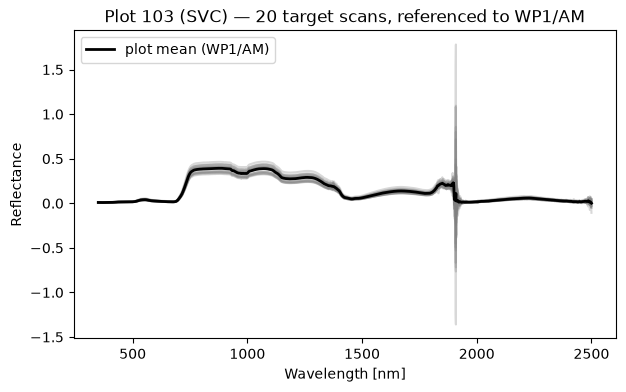

In [17]:
# Step 4a: reflectance of every target scan of Plot 103, for both panels (the same targets referenced two ways):
# the panel signal is interpolated to the scan time and the reflectance formula is applied (c_cloud = 1 here; its
# uncertainty is added in the systematic propagation, Step 7)
R_dict, E_interp_dict = {}, {}

for panel_name, (E_start, E_end, E_start_t, E_end_t, rho) in {
    'AM': (E_start_AM, E_end_AM, E_start_t_AM, E_end_t_AM, rho_interp_AM),
    'LM': (E_start_LM, E_end_LM, E_start_t_LM, E_end_t_LM, rho_interp_LM),
}.items():
    R_list, E_interp_list = [], []
    for i in range(len(L['103'][0])):
        DN = L['103'][0][i]
        DN_t = time_to_seconds(L['103'][1][i])
        c_cloud = np.ones(len(DN))
        E_interp = np.squeeze(irradiance_interpol(E_start, E_end, E_start_t, E_end_t, DN_t))
        R = refl_calculator(DN, E_interp, rho, c_cloud)
        R_list.append(R)
        E_interp_list.append(E_interp)
    R_dict['103_' + panel_name] = R_list
    E_interp_dict['103_' + panel_name] = E_interp_list[-1]

# Step 4b: plot all scans (grey) and the plot mean
plt.figure(figsize=(7, 4))
for r in R_dict['103_AM']:
    plt.plot(wvls, r, color='grey', alpha=0.3)
plt.plot(wvls, np.mean(R_dict['103_AM'], axis=0), color='k', linewidth=2, label='plot mean (WP1/AM)')
plt.xlabel('Wavelength [nm]'); plt.ylabel('Reflectance'); plt.legend(); plt.title('Plot 103 (SVC) — 20 target scans, referenced to WP1/AM')
plt.show()

## SVC - Step 5: random uncertainty (sensor noise)

In [18]:
# Step 5a: every panel scan expressed as a ratio to the mean panel signal (a number close to 1)
R_WR_dict = {}
for panel_name, (WR_readings, E_ref) in {
    'AM': (WR_AM['103'][0], E_start_AM),
    'LM': (WR_LM['103'][0], E_start_LM),
}.items():
    R_WR_dict['103_' + panel_name] = [scan / E_ref for scan in WR_readings]

# Step 5b: the standard error of that ratio over the repeated panel scans is the fractional random uncertainty
# (also used for the target signal); a small positive floor avoids zero uncertainty
WR_sd = {}
for key in R_WR_dict.keys():
    N = len(R_WR_dict[key])
    sd = np.std(R_WR_dict[key], axis=0, ddof=1) / np.sqrt(N)
    eps = 1e-6 * np.nanmax(sd)
    WR_sd[key] = np.maximum(sd, eps)

## SVC - Step 6: systematic uncertainty (clouds and plot inhomogeneity)

In [19]:
# Step 6: cloud uncertainty and plot inhomogeneity, as for the ASD (u_cloud_estimation defined above)
WR_DN_dict = {
    '103_AM': WR_AM['103'][0], '105_AM': WR_AM['105'][0],
    '103_LM': WR_LM['103'][0], '105_LM': WR_LM['105'][0],
}
u_cloud_rel = u_cloud_estimation(WR_DN_dict, wvls)

vnir = np.ones(len(np.arange(350, 1001)))
swir1 = np.ones(len(np.arange(1001, 1801)))
swir2 = np.ones(len(np.arange(1801, 2501)))

def cloud_curve(key):
    return np.concatenate([u_cloud_rel[key]['pair1']['residuals_rel_mean'] * vnir,
                            u_cloud_rel[key]['pair2']['residuals_rel_mean'] * swir1,
                            u_cloud_rel[key]['pair3']['residuals_rel_mean'] * swir2])

plot_u_clouds = np.mean(np.stack([cloud_curve('103_LM'), cloud_curve('103_AM')], axis=0), axis=0)

plot_sd, plot_mean_refl, plot_inhomogeneity, plot_err_corr = {}, {}, {}, {}
for key in R_dict.keys():
    plot_mean_refl[key] = np.maximum(np.mean(R_dict[key], axis=0), 1e-9)
    plot_sd[key] = np.std(R_dict[key], axis=0) / plot_mean_refl[key] * 100
    plot_inhomogeneity[key] = (plot_sd[key] / 100 * plot_mean_refl[key] - plot_u_clouds / 100 * plot_mean_refl[key]) / plot_mean_refl[key] * 100
    plot_err_corr[key] = np.corrcoef(np.stack(R_dict[key], axis=0), rowvar=False)

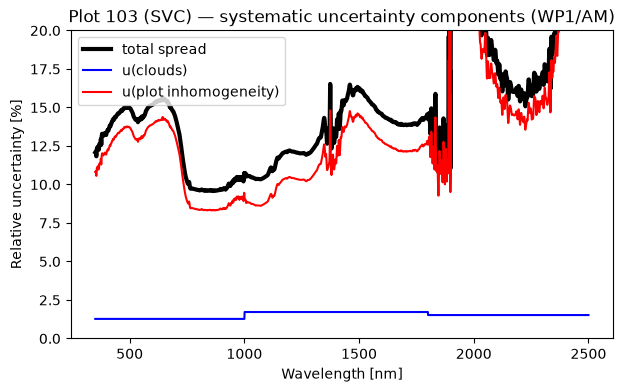

In [20]:
plt.figure(figsize=(7, 4))
plt.plot(wvls, plot_sd['103_AM'], 'k', linewidth=3, label='total spread')
plt.plot(wvls, plot_u_clouds, 'b', label='u(clouds)')
plt.plot(wvls, plot_inhomogeneity['103_AM'], 'r', label='u(plot inhomogeneity)')
plt.ylim(0, 20); plt.xlabel('Wavelength [nm]'); plt.ylabel('Relative uncertainty [%]')
plt.legend(); plt.title('Plot 103 (SVC) — systematic uncertainty components (WP1/AM)')
plt.show()

## SVC - Step 7: combination with punpy

In [21]:
# Step 7: same propagation as for the ASD (regularize_corr defined above)
err_corr_plot = regularize_corr(np.full((len(wvls), len(wvls)), 1.0))
rho_err_corr = regularize_corr(np.full((len(wvls), len(wvls)), 1.0))

prop = punpy.MCPropagation(realisations_n)
u_rand_dict, u_syst_dict, u_combined_dict = {}, {}, {}
err_corr_rand, err_corr_syst, err_corr_combined = {}, {}, {}

for key in R_dict.keys():
    panel = key.split('_')[1]
    E_start, E_end, E_start_t, E_end_t = (E_start_AM, E_end_AM, E_start_t_AM, E_end_t_AM) if panel == 'AM' \
        else (E_start_LM, E_end_LM, E_start_t_LM, E_end_t_LM)
    rho = rho_interp_AM if panel == 'AM' else rho_interp_LM
    u_rho_abs = u_rho_am_abs if panel == 'AM' else u_rho_lm_abs
    u_rand_panel = WR_sd[key] / 100 * E_start

    DN = np.mean(L['103'][0], axis=0)
    DN_t = time_to_seconds(L['103'][1][-1])
    E_interp = E_interp_dict[key]
    c_cloud = np.ones(len(DN))
    u_syst_plot = np.maximum(plot_inhomogeneity[key] / 100 * DN, 1e-9)
    err_corr_clouds = regularize_corr(plot_err_corr[key])

    u_E_interp_rand, _ = prop.propagate_random(
        irradiance_interpol,
        [E_start, E_end, np.asarray(E_start_t), np.asarray(E_end_t), np.asarray(DN_t)],
        [u_rand_panel, u_rand_panel, np.asarray(0.1), np.asarray(0.1), np.asarray(0.1)],
        ['rand'] * 5, return_corr=True)
    u_E_interp_rand = np.squeeze(u_E_interp_rand)

    u_R_rand, corr_R_rand = prop.propagate_random(
        refl_calculator, [DN, E_interp, rho, c_cloud],
        [u_rand_panel, u_E_interp_rand, np.zeros(len(rho)), np.zeros(len(c_cloud))],
        ['rand'] * 4, return_corr=True)

    u_R_syst, corr_R_syst = prop.propagate_systematic(
        refl_calculator, [DN, E_interp, rho, c_cloud],
        [u_syst_plot, np.zeros(len(E_interp)), u_rho_abs, plot_u_clouds / 100],
        [err_corr_plot, 'syst', rho_err_corr, err_corr_clouds], return_corr=True)

    cov_total = ctm.convert_corr_to_cov(corr_R_rand, u_R_rand) + ctm.convert_corr_to_cov(corr_R_syst, u_R_syst)
    u_total = ctm.uncertainty_from_covariance(cov_total)
    err_corr_rand[key] = corr_R_rand
    err_corr_syst[key] = corr_R_syst
    err_corr_combined[key] = ctm.correlation_from_covariance(cov_total)

    u_rand_dict[key] = u_R_rand
    u_syst_dict[key] = u_R_syst
    u_combined_dict[key] = u_total
    print(f"{key}: done")

/opt/miniconda3/lib/python3.12/site-packages/comet_maths/linear_algebra/matrix_conversion.py:32: UserWarning: 'where' used without 'out', expect uninitialized memory in output. If this is intentional, use out=None.
  correlation = np.divide(covariance, outer_v, where=outer_v != 0)


103_AM: done


103_LM: done


## SVC - Step 8: comparison of the combined uncertainty with the campaign result

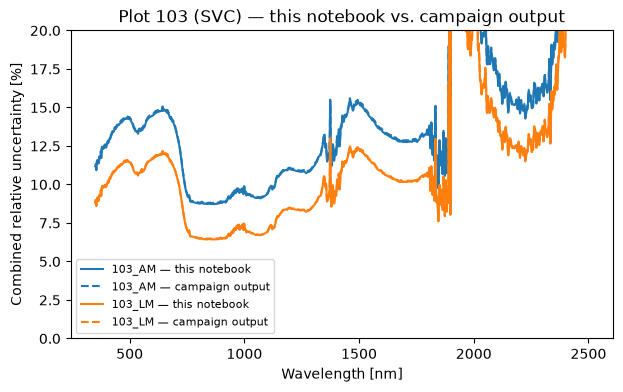

103_AM: u_total median relative difference vs. campaign = 0.68% (max 0.75%)
103_AM: R(400nm) this notebook = 0.008724, campaign = 0.008724 (relative diff 0.000%)
103_LM: u_total median relative difference vs. campaign = 0.50% (max 0.71%)
103_LM: R(400nm) this notebook = 0.008185, campaign = 0.008185 (relative diff 0.000%)


In [22]:
# Step 8: combined relative uncertainty of this notebook (solid) and of the campaign result (dashed), and their difference
campaign_total = pd.read_csv(f"{DATA_DIR}/../case-intercomparison-plot103/svc_u_total_all_plots.csv", index_col=0)
campaign_R = pd.read_csv(f"{DATA_DIR}/../case-intercomparison-plot103/campaign_svc_reflectance.csv")

plt.figure(figsize=(7, 4))
for key, color in [('103_AM', 'tab:blue'), ('103_LM', 'tab:orange')]:
    rel_total = u_combined_dict[key] / plot_mean_refl[key] * 100
    plt.plot(wvls, rel_total, color=color, label=f'{key} — this notebook')
    off = campaign_total[key].values / plot_mean_refl[key] * 100
    plt.plot(wvls, off, color=color, linestyle='--', label=f'{key} — campaign output')
plt.ylim(0, 20); plt.xlabel('Wavelength [nm]'); plt.ylabel('Combined relative uncertainty [%]')
plt.legend(fontsize=8); plt.title('Plot 103 (SVC) — this notebook vs. campaign output')
plt.show()

idx400 = wvls.index(400.0)
for key, ref_col in [('103_AM', 'R_WP1'), ('103_LM', 'R_WP2')]:
    diff = np.abs(u_combined_dict[key] - campaign_total[key].values) / (campaign_total[key].values + 1e-12) * 100
    print(f"{key}: u_total median relative difference vs. campaign = {np.nanmedian(diff):.2f}% (max {np.nanmax(diff):.2f}%)")
    computed_R = plot_mean_refl[key][idx400]
    off_R = campaign_R[ref_col].iloc[0]
    print(f"{key}: R(400nm) this notebook = {computed_R:.6f}, campaign = {off_R:.6f} (relative diff {abs(computed_R-off_R)/off_R*100:.3f}%)")

## SVC - Step 9: vegetation indices

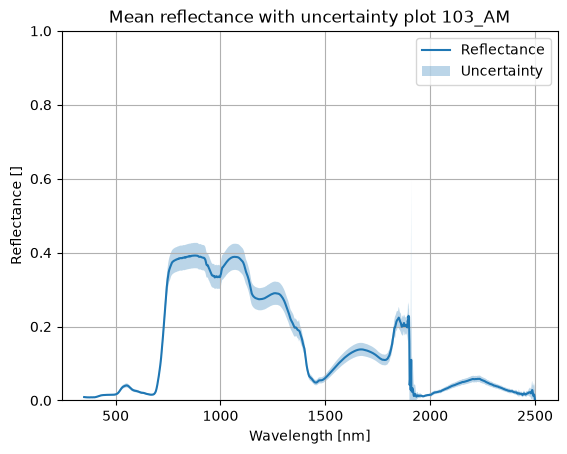

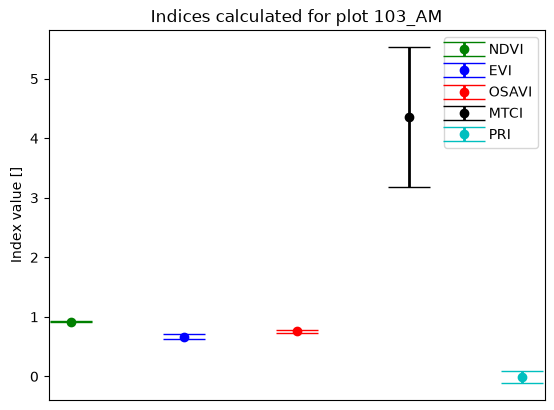

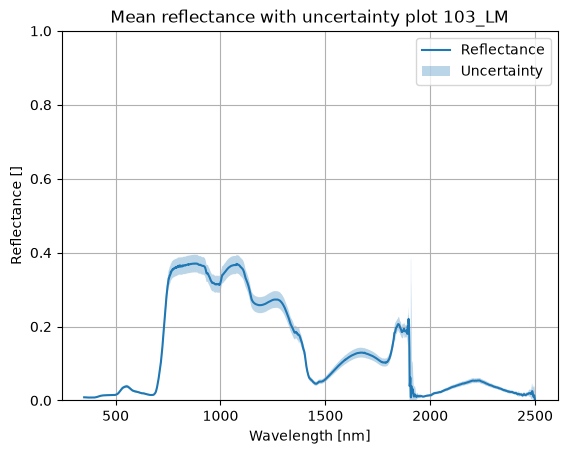

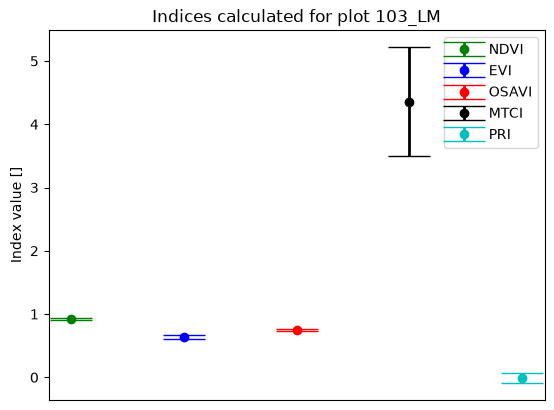

,plot ids,NDVI,EVI,OSAVI,MTCI,PRI
0,103_AM,0.920541,0.668512,0.759571,4.357186,-0.015298
1,103_LM,0.920792,0.640672,0.747131,4.354839,-0.015030


,plot ids,NDVI,NDVI rand,NDVI syst,EVI,EVI rand,EVI syst,OSAVI,OSAVI rand,OSAVI syst,MTCI,MTCI rand,MTCI syst,PRI,PRI rand,PRI syst
0,103_AM,0.013164,0.000482,0.013256,0.047236,0.000596,0.048049,0.025486,0.000356,0.025767,1.173004,0.011286,1.146390,0.099005,0.001931,0.098159
1,103_LM,0.010438,0.000357,0.010404,0.034343,0.000407,0.034085,0.019428,0.000257,0.019664,0.862993,0.008256,0.880447,0.077992,0.001439,0.077950


In [23]:
# Step 9: same functions as for the ASD (Step 9a-b); run for the SVC (both panels)
df_indices_SVC, df_unc_SVC = vegetation_indices(
    R_dict, pd.DataFrame(u_combined_dict), pd.DataFrame(u_rand_dict), pd.DataFrame(u_syst_dict),
    err_corr_rand, err_corr_syst, err_corr_combined)
display(df_indices_SVC)
display(df_unc_SVC)

## SVC - Step 10: comparison with the campaign indices

In [24]:
# Step 10: campaign rows SVC_WP1 and SVC_WP2
df_cmp_SVC = compare_with_campaign(df_indices_SVC, df_unc_SVC, {"103_AM": 26, "103_LM": 27})
df_cmp_SVC

,key,index,value_computed,value_campaign,u_c_computed,u_c_campaign,u_rand_computed,u_rand_campaign,u_syst_computed,u_syst_campaign,u_c_rel_diff_%
0,103_AM,NDVI,0.920541,0.920541,0.013164,0.013017,0.000482,0.000482,0.013256,0.013284,1.124185
1,103_AM,EVI,0.668512,0.668512,0.047236,0.047129,0.000596,0.000482,0.048049,0.013284,0.227115
2,103_AM,OSAVI,0.759571,0.759571,0.025486,0.025747,0.000356,0.000354,0.025767,0.025837,-1.014328
3,103_AM,MTCI,4.357186,4.357186,1.173004,1.159081,0.011286,0.011337,1.146390,1.148550,1.201237
4,103_AM,PRI,-0.015298,-0.015298,0.099005,0.097197,0.001931,0.099026,0.098159,0.096877,1.860855
5,103_LM,NDVI,0.920792,0.920792,0.010438,0.010330,0.000357,0.000359,0.010404,0.010377,1.041392
6,103_LM,EVI,0.640672,0.640672,0.034343,0.033902,0.000407,0.000359,0.034085,0.010377,1.300900
7,103_LM,OSAVI,0.747131,0.747131,0.019428,0.019457,0.000257,0.000257,0.019664,0.019450,-0.149005
8,103_LM,MTCI,4.354839,4.354839,0.862993,0.858179,0.008256,0.008351,0.880447,0.865638,0.560918
9,103_LM,PRI,-0.015030,-0.015030,0.077992,0.078355,0.001439,0.078496,0.077950,0.079393,-0.463555


---

**Code:** Mike Werfeli (mike.werfeli@geo.uzh.ch)  
**Training material:** L. Mihai (laura.mihai@inflpr.ro)